In [1]:
# Imports
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

# Data files
stage_directory = next(
    candidate for candidate in [Path.cwd(), *Path.cwd().parents]
    if (candidate / "data" / "TrainingSetValues.csv").is_file()
)
training_set_values_path = stage_directory / "data" / "TrainingSetValues.csv"
training_set_labels_path = stage_directory / "data" / "TrainingSetLabels.csv"
test_set_values_path = stage_directory / "data" / "TestSetValues.csv"
submission_format_path = stage_directory / "data" / "SubmissionFormat.csv"

training_set_values = pd.read_csv(training_set_values_path)
training_amounts = training_set_values["amount_tsh"]

training_set_labels = pd.read_csv(training_set_labels_path)
test_set_values = pd.read_csv(test_set_values_path)
test_amounts = test_set_values["amount_tsh"]
submission_format = pd.read_csv(submission_format_path)

In [2]:
# Enhanced 'describe' dataset
def describe_numeric_series(
    series: pd.Series,
    *,
    percentiles=None
) -> pd.Series:
    if percentiles is None:
        percentiles = [
            0.01, 0.05, 0.10,
            0.25, 0.50, 0.75,
            0.90, 0.95, 0.99
        ]

    total_count = len(series)
    non_missing_count = series.notna().sum()

    description = series.describe(
        percentiles=percentiles
    )

    additional_statistics = pd.Series({
        "missing": series.isna().sum(),
        "missing %": series.isna().mean() * 100,
        "zero": series.eq(0).sum(),
        "zero %": series.eq(0).mean() * 100,
        "positive": series.gt(0).sum(),
        "positive % of valid": (
            series.gt(0).sum() / non_missing_count * 100
            if non_missing_count > 0
            else float("nan")
        ),
        "unique": series.nunique()
    })

    return pd.concat([
        description,
        additional_statistics
    ])

In [3]:
# Highest observations
def highest_observations(
    series: pd.Series,
    *,
    n: int = 50,
    value_name: str = "amount_tsh"
) -> pd.DataFrame:
    """Return the n highest observations with their indices and frequencies."""

    clean_series = pd.to_numeric(
        series,
        errors="coerce"
    ).dropna()

    frequencies = clean_series.value_counts()

    result = (
        clean_series
        .nlargest(n)
        .rename_axis("source_index")
        .reset_index(name=value_name)
    )

    result["frequency"] = result[value_name].map(frequencies)

    return result

In [4]:
# Comparing highest observations
def compare_highest_observations(
    training_data: pd.Series,
    test_data: pd.Series,
    *,
    n: int = 50,
    value_name: str = "amount_tsh"
) -> dict[str, pd.DataFrame]:

    training = pd.to_numeric(
        training_data,
        errors="coerce"
    ).dropna()

    test = pd.to_numeric(
        test_data,
        errors="coerce"
    ).dropna()

    combined = pd.concat(
        {
            "Training": training,
            "Test": test
        },
        names=["dataset", "source_index"]
    )

    combined_frequencies = combined.value_counts()

    combined_highest = (
        combined
        .nlargest(n)
        .rename(value_name)
        .reset_index()
    )

    combined_highest["frequency"] = (
        combined_highest[value_name]
        .map(combined_frequencies)
    )

    return {
        "Combined": combined_highest,
        "Training": highest_observations(
            training,
            n=n,
            value_name=value_name
        ),
        "Test": highest_observations(
            test,
            n=n,
            value_name=value_name
        )
    }

In [5]:
def compare_highest_distinct_values(
    training_data: pd.Series,
    test_data: pd.Series,
    *,
    n: int = 50,
    value_name: str = "Value"
) -> pd.DataFrame:

    training = pd.to_numeric(
        training_data,
        errors="coerce"
    ).dropna()

    test = pd.to_numeric(
        test_data,
        errors="coerce"
    ).dropna()

    counts = pd.concat(
        [
            training.value_counts().rename("Training"),
            test.value_counts().rename("Test")
        ],
        axis=1
    ).fillna(0).astype(int)

    counts["Combined"] = (
        counts["Training"] +
        counts["Test"]
    )

    return (
        counts
        .sort_index(ascending=False)
        .head(n)
        .rename_axis(value_name)
        .reset_index()
        [[
            value_name,
            "Combined",
            "Training",
            "Test"
        ]]
    )

In [6]:
# Plots high occurrence value frequencies across multiple sets
def plot_top_value_frequencies(
    data_a: pd.Series,
    data_b: pd.Series,
    *,
    labels: tuple[str, str] = ("Training", "Test"),
    n: int = 20,
    exclude_zero: bool = False,
    percentages: bool = False,
    figsize: tuple[int, int] = (18, 8)
) -> pd.DataFrame:
    """
    Plot the most frequent values across two Series:

    1. Combined
    2. Dataset A
    3. Dataset B

    The top values are selected from the combined data and reused for
    all three plots.

    Returns a DataFrame containing the plotted frequencies.
    """

    series_a = pd.Series(data_a).dropna()
    series_b = pd.Series(data_b).dropna()

    if exclude_zero:
        series_a = series_a[series_a != 0]
        series_b = series_b[series_b != 0]

    combined = pd.concat(
        [series_a, series_b],
        ignore_index=True
    )

    # Select the top n values based on combined frequency.
    top_values = (
        combined
        .value_counts()
        .head(n)
        .index
    )

    frequencies = pd.DataFrame({
        "Combined": combined.value_counts().reindex(
            top_values,
            fill_value=0
        ),
        labels[0]: series_a.value_counts().reindex(
            top_values,
            fill_value=0
        ),
        labels[1]: series_b.value_counts().reindex(
            top_values,
            fill_value=0
        )
    })

    if percentages:
        frequencies = frequencies.astype(float)

        frequencies["Combined"] /= len(combined)
        frequencies[labels[0]] /= len(series_a)
        frequencies[labels[1]] /= len(series_b)

        frequencies *= 100

    # Reverse the order so the most frequent value appears at the top.
    plot_data = frequencies.iloc[::-1]
    y_positions = np.arange(len(plot_data))

    fig, axes = plt.subplots(
        nrows=1,
        ncols=3,
        figsize=figsize,
        sharey=True
    )

    for ax, column_name in zip(axes, frequencies.columns):
        ax.barh(
            y_positions,
            plot_data[column_name],
            edgecolor="black"
        )

        ax.set_title(column_name)
        ax.set_xlabel(
            "Percentage of observations"
            if percentages
            else "Frequency"
        )

        ax.set_yticks(y_positions)
        ax.set_yticklabels(plot_data.index)

    axes[0].set_ylabel("Amount TSH")

    fig.suptitle(
        f"{n} most frequent amount_tsh values"
    )

    fig.tight_layout()
    plt.show()

    return frequencies

In [7]:
# Get enhanced description across multiple datasets
def compare_numeric_descriptions(
    datasets: dict[str, pd.Series],
    *,
    percentiles=None
) -> pd.DataFrame:
    return pd.concat(
        {
            name: describe_numeric_series(
                series,
                percentiles=percentiles
            )
            for name, series in datasets.items()
        },
        axis=1
    )

In [8]:
# Plotting helper

# Usage:
#fig, axes, amount_summary = plot_distribution_comparison(
#    training_amounts,
#    test_amounts,
#    labels=("Training", "Test"),
#    lower_limit=0,
#    upper_quantile=0.95,
#    exclude_zero=True,
#    show_mean=True,
#    show_median=True,
#    title="Distribution of positive amount_tsh values"
#)
#
#plt.show()
#
#amount_summary

# I'm keeping this import in the cell, since it's very much local to it for now
# No need cell? No need import

from collections.abc import Sequence

def plot_distribution_comparison(
    data_a,
    data_b,
    *,
    labels: tuple[str, str] = ("Dataset A", "Dataset B"),
    bins: int | Sequence[float] = 40,
    density: bool = True,
    lower_limit: float | None = None,
    upper_quantile: float | None = None,
    exclude_zero: bool = False,
    show_mean: bool = True,
    show_median: bool = False,
    share_y: bool = True,
    figsize: tuple[float, float] = (14, 5),
    title: str | None = None,
):
    """
    Plot two numeric distributions side by side using shared bin boundaries.

    Any lower limit or upper quantile is applied consistently to both
    datasets. The upper quantile is calculated from their combined values.

    Returns
    -------
    fig
        The Matplotlib figure.
    axes
        The two Matplotlib axes.
    summary
        Descriptive statistics for the values actually plotted.
    """

    if len(labels) != 2:
        raise ValueError("labels must contain exactly two names")

    if upper_quantile is not None and not 0 < upper_quantile <= 1:
        raise ValueError("upper_quantile must be between 0 and 1")

    def clean_numeric(data, name: str) -> pd.Series:
        series = pd.to_numeric(
            pd.Series(data, name=name),
            errors="coerce"
        )

        return (
            series
            .replace([np.inf, -np.inf], np.nan)
            .dropna()
        )

    original_series = [
        clean_numeric(data_a, labels[0]),
        clean_numeric(data_b, labels[1]),
    ]

    combined = pd.concat(original_series, ignore_index=True)

    if combined.empty:
        raise ValueError("Neither dataset contains valid numeric values")

    upper_limit = (
        combined.quantile(upper_quantile)
        if upper_quantile is not None
        else None
    )

    def apply_filters(series: pd.Series) -> pd.Series:
        filtered = series.copy()

        if lower_limit is not None:
            filtered = filtered[filtered >= lower_limit]

        if upper_limit is not None:
            filtered = filtered[filtered <= upper_limit]

        if exclude_zero:
            filtered = filtered[filtered != 0]

        return filtered

    filtered_series = [
        apply_filters(series)
        for series in original_series
    ]

    if any(series.empty for series in filtered_series):
        raise ValueError(
            "At least one dataset has no values remaining after filtering"
        )

    combined_filtered = pd.concat(
        filtered_series,
        ignore_index=True
    )

    # Both plots use exactly the same bin boundaries.
    if isinstance(bins, int):
        shared_bins = np.histogram_bin_edges(
            combined_filtered,
            bins=bins
        )
    else:
        shared_bins = np.asarray(bins)

    fig, axes = plt.subplots(
        nrows=1,
        ncols=2,
        figsize=figsize,
        sharex=True,
        sharey=share_y
    )

    summary_rows = []

    for ax, original, filtered, label in zip(
        axes,
        original_series,
        filtered_series,
        labels
    ):
        ax.hist(
            filtered,
            bins=shared_bins,
            density=density,
            edgecolor="black"
        )

        if show_mean:
            mean = filtered.mean()

            ax.axvline(
                mean,
                linestyle="--",
                linewidth=2,
                label=f"Mean: {mean:,.2f}"
            )

        if show_median:
            median = filtered.median()

            ax.axvline(
                median,
                linestyle=":",
                linewidth=2,
                label=f"Median: {median:,.2f}"
            )

        ax.set_title(label)
        ax.set_xlabel("Value")
        ax.set_ylabel("Density" if density else "Frequency")

        if show_mean or show_median:
            ax.legend()

        summary_rows.append({
            "dataset": label,
            "original_count": len(original),
            "plotted_count": len(filtered),
            "excluded_count": len(original) - len(filtered),
            "mean": filtered.mean(),
            "median": filtered.median(),
            "std": filtered.std(),
            "min": filtered.min(),
            "max": filtered.max(),
        })

    if title is None:
        description = []

        if upper_quantile is not None:
            description.append(
                f"up to combined {upper_quantile:.0%} percentile"
            )

        if exclude_zero:
            description.append("excluding zero")

        suffix = (
            f" — {', '.join(description)}"
            if description
            else ""
        )

        title = f"Distribution comparison{suffix}"

    fig.suptitle(title)
    fig.tight_layout()

    summary = (
        pd.DataFrame(summary_rows)
        .set_index("dataset")
    )

    return fig, axes, summary

## amount_tsh
### Data Type: float64

**Difficult therefore potentially useful!**

The DrivenData page appears to have incorrectly expanded amount_tsh as total static head.

The documentation for the underlying Tanzanian Water Point Mapping data defines AMOUNT_TSH as the amount of payment received for water use.

When I deal with this data I will assume payment received. 


In [9]:
# Describe
amount_summary = compare_numeric_descriptions({
    "Training": training_amounts,
    "Test": test_amounts
})

amount_summary

,Training,Test
count,59400.000000,14850.000000
mean,317.650385,322.826983
std,2997.574558,2510.968644
min,0.000000,0.000000
1%,0.000000,0.000000
5%,0.000000,0.000000
10%,0.000000,0.000000
25%,0.000000,0.000000
50%,0.000000,0.000000
75%,20.000000,25.000000


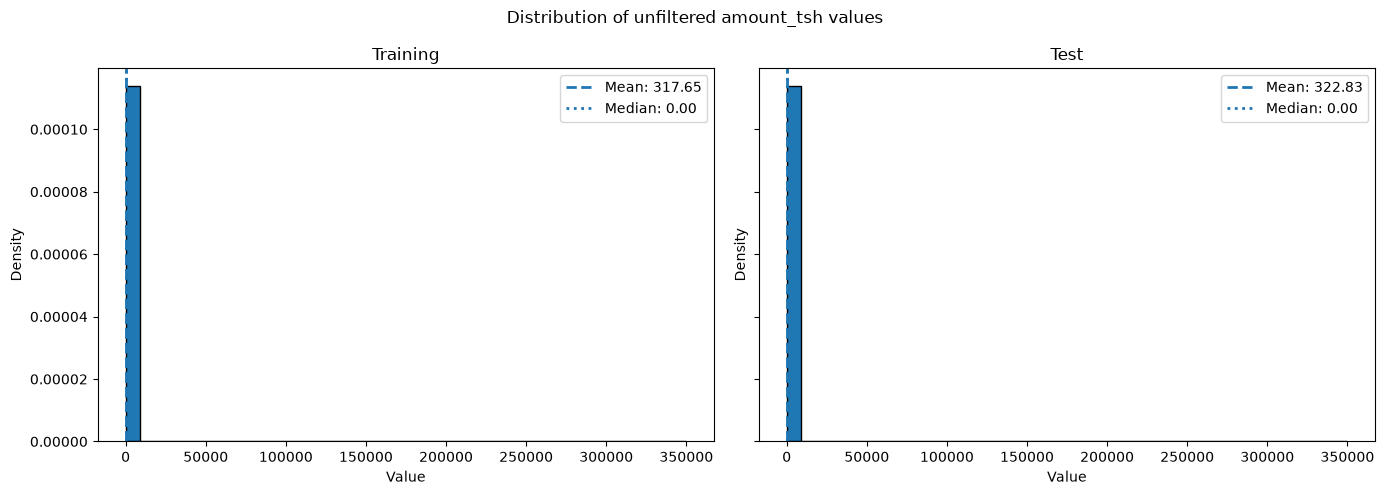

,original_count,plotted_count,excluded_count,mean,median,std,min,max
dataset,,,,,,,,
Training,59400,59400,0,317.650385,0.0,2997.574558,0.0,350000.0
Test,14850,14850,0,322.826983,0.0,2510.968644,0.0,200000.0


In [10]:
fig, axes, amount_summary = plot_distribution_comparison(
    training_amounts,
    test_amounts,
    labels=("Training", "Test"),
    show_mean=True,
    show_median=True,
    title="Distribution of unfiltered amount_tsh values"
)

plt.show()

amount_summary

### Observation
The standard deviation is much larger than the mean. Interpreting the data using a symmetric mean ± standard-deviation range would extend deeply into impossible negative values, confirming that the mean and standard deviation are poor summaries for this bounded, highly right-skewed distribution.

We have 70.1% zero values, then the vast majority of the remainder accounted for by 25,000. Nevertheless, there are values all the way up to 350,000

First filter - limit values to the 99th percentile.

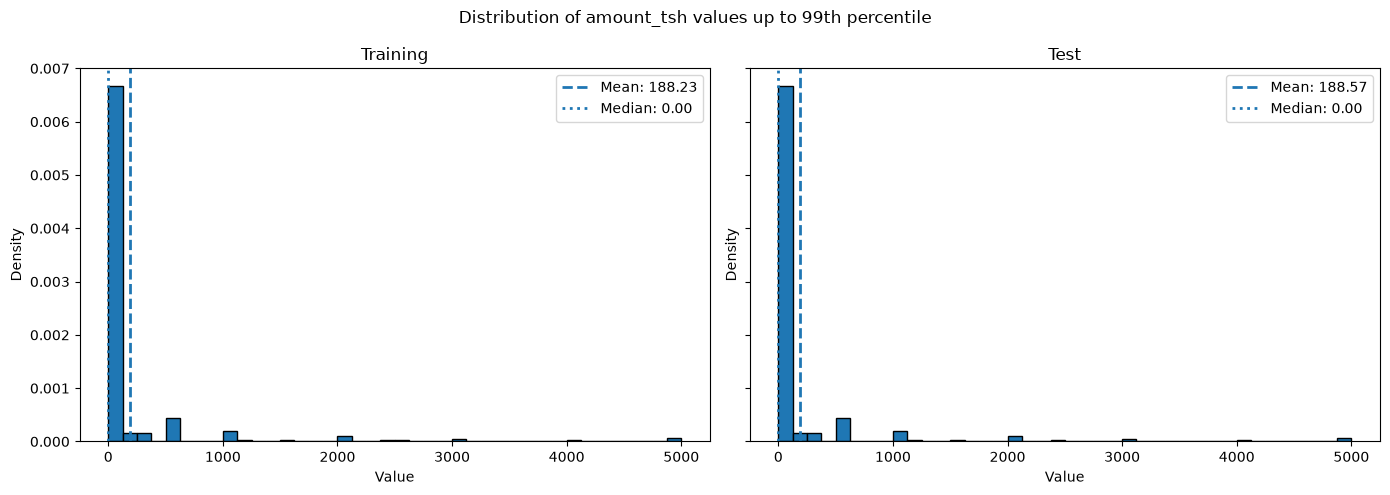

,original_count,plotted_count,excluded_count,mean,median,std,min,max
dataset,,,,,,,,
Training,59400,58930,470,188.227267,0.0,638.011768,0.0,5000.0
Test,14850,14721,129,188.566042,0.0,639.575851,0.0,5000.0


In [11]:
# First filter - 99th percentile upper limit histogram
fig, axes, amount_summary = plot_distribution_comparison(
    training_amounts,
    test_amounts,
    labels=("Training", "Test"),
    upper_quantile=0.99,
    exclude_zero=False,
    show_mean=True,
    show_median=True,
    title="Distribution of amount_tsh values up to 99th percentile"
)

plt.show()

amount_summary

### Observation
Now there's some visibility of non-zero numbers, and the standard deviation of both datasets has diminished significantly.  Given the shape of the distribution that is becoming apparent, SD won't actually be a great measure going forward - we seem to have some zero-skewed distribution which probably has a special name, and way of being treated here!

Anyway, zero is still dominating the historgrams, although we can already see some similarities emerging: Extra peaks at maybe 1000,2000,3000 etc., and overall a very similar distribution density. 

I think next we need to look at this data without the zeroes.

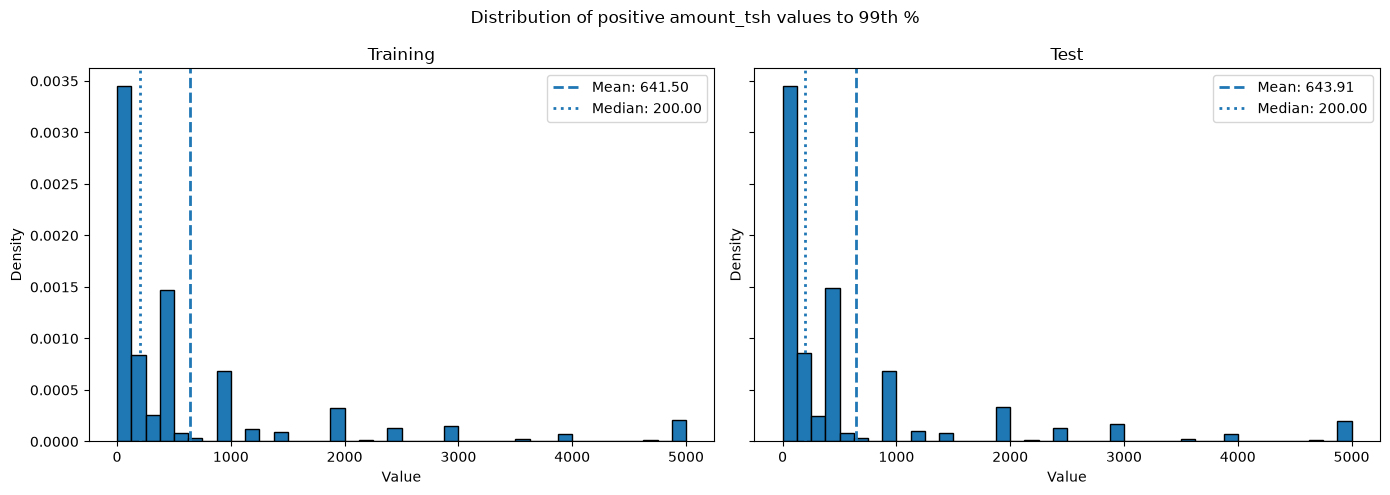

,original_count,plotted_count,excluded_count,mean,median,std,min,max
dataset,,,,,,,,
Training,59400,17291,42109,641.503259,200.0,1047.173561,0.2,5000.0
Test,14850,4311,10539,643.906449,200.0,1050.616033,0.2,5000.0


In [12]:
fig, axes, amount_summary = plot_distribution_comparison(
    training_amounts,
    test_amounts,
    labels=("Training", "Test"),
    lower_limit=0,
    upper_quantile=0.99,
    exclude_zero=True,
    show_mean=True,
    show_median=True,
    title="Distribution of positive amount_tsh values to 99th %"
)

plt.show()

amount_summary

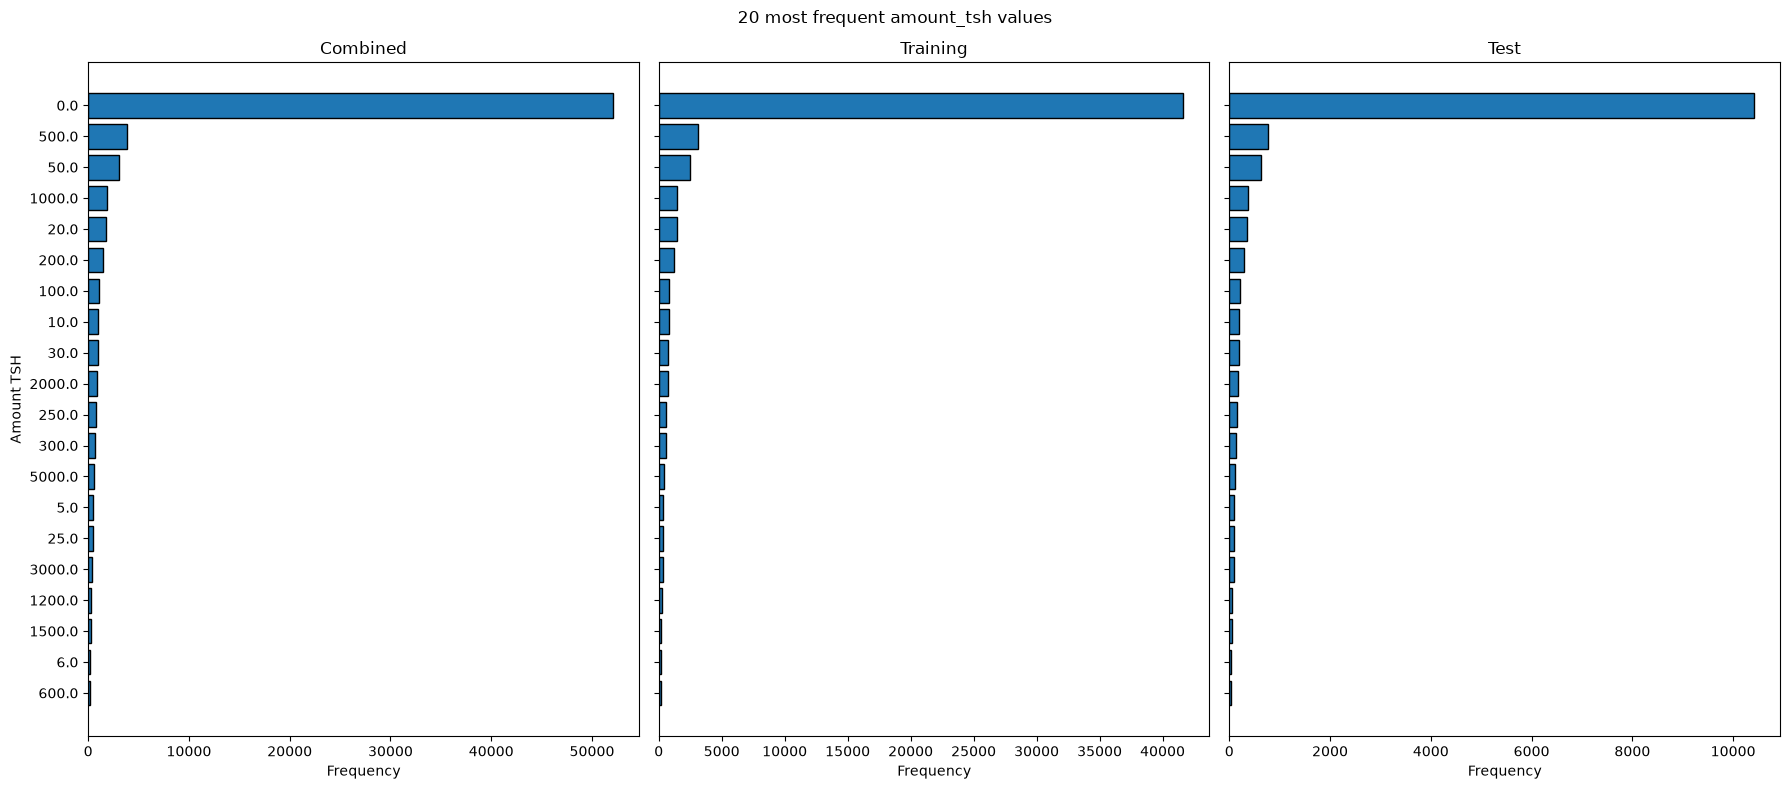

,Combined,Training,Test
amount_tsh,,,
0.0,52049,41639,10410
500.0,3874,3102,772
50.0,3103,2472,631
1000.0,1858,1488,370
20.0,1812,1463,349
200.0,1516,1220,296
100.0,1034,816,218
10.0,995,806,189
30.0,929,743,186


In [13]:
amount_frequencies = plot_top_value_frequencies(
    training_amounts,
    test_amounts,
    labels=("Training", "Test"),
    n=20
)

amount_frequencies

In [14]:
highest_amounts = compare_highest_distinct_values(
    training_amounts,
    test_amounts,
    n=20
)

highest_amounts

,Value,Combined,Training,Test
0,350000.0,1,1,0
1,250000.0,1,1,0
2,200000.0,2,1,1
3,170000.0,1,1,0
4,138000.0,1,1,0
5,120000.0,1,1,0
6,117000.0,7,7,0
7,100000.0,4,3,1
8,70000.0,2,1,1
9,60000.0,2,1,1


In [15]:
print("Skewness:", training_amounts.skew())
print("Kurtosis:", training_amounts.kurt())

Skewness: 57.80779994588519
Kurtosis: 4903.543101955053


In [16]:
positive_amounts = training_amounts[
    training_amounts > 0
]

positive_to_99 = positive_amounts[
    positive_amounts <= positive_amounts.quantile(0.99)
]

distribution_shapes = pd.DataFrame({
    "Full data": {
        "Count": training_amounts.count(),
        "Mean": training_amounts.mean(),
        "Median": training_amounts.median(),
        "Skewness": training_amounts.skew(),
        "Excess kurtosis": training_amounts.kurt(),
        "Maximum": training_amounts.max()
    },
    "Positive only": {
        "Count": positive_amounts.count(),
        "Mean": positive_amounts.mean(),
        "Median": positive_amounts.median(),
        "Skewness": positive_amounts.skew(),
        "Excess kurtosis": positive_amounts.kurt(),
        "Maximum": positive_amounts.max()
    },
    "Positive to 99th percentile": {
        "Count": positive_to_99.count(),
        "Mean": positive_to_99.mean(),
        "Median": positive_to_99.median(),
        "Skewness": positive_to_99.skew(),
        "Excess kurtosis": positive_to_99.kurt(),
        "Maximum": positive_to_99.max()
    }
}).T

distribution_shapes

,Count,Mean,Median,Skewness,Excess kurtosis,Maximum
Full data,59400.0,317.650385,0.0,57.807800,4903.543102,350000.0
Positive only,17761.0,1062.351942,250.0,32.487610,1526.794982,350000.0
Positive to 99th percentile,17583.0,753.616155,250.0,3.278696,12.867316,11000.0


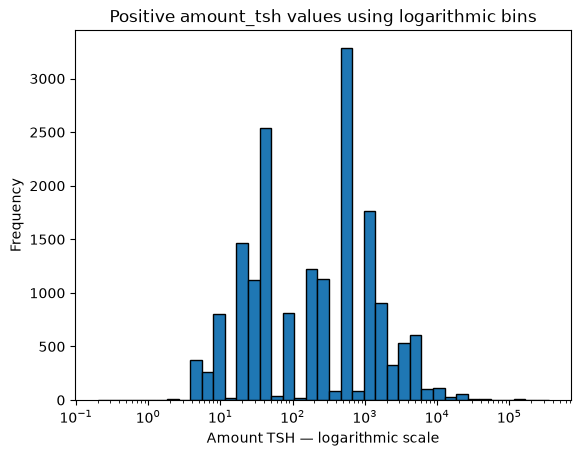

In [17]:
import numpy as np
import matplotlib.pyplot as plt

positive_training = training_amounts[training_amounts > 0]

log_bins = np.logspace(
    np.log10(positive_training.min()),
    np.log10(positive_training.max()),
    40
)

plt.hist(
    positive_training,
    bins=log_bins,
    edgecolor="black"
)

plt.xscale("log")
plt.xlabel("Amount TSH — logarithmic scale")
plt.ylabel("Frequency")
plt.title("Positive amount_tsh values using logarithmic bins")
plt.show()

Log skewness: 0.022063175595370833
Log excess kurtosis: -0.7118065164972185


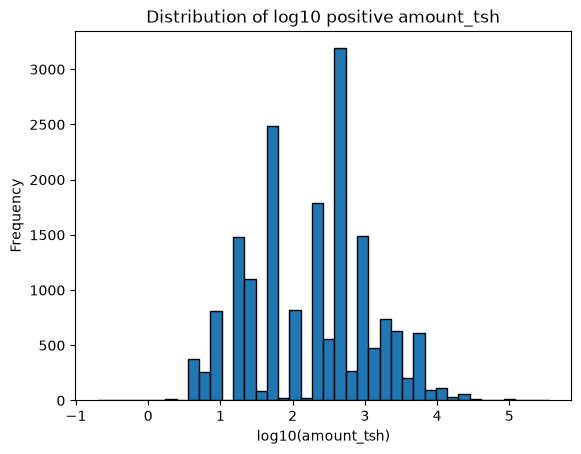

In [18]:
log_training_amounts = np.log10(
    training_amounts[training_amounts > 0]
)

print("Log skewness:", log_training_amounts.skew())
print("Log excess kurtosis:", log_training_amounts.kurt())

log_training_amounts.plot(
    kind="hist",
    bins=40,
    edgecolor="black"
)

plt.xlabel("log10(amount_tsh)")
plt.ylabel("Frequency")
plt.title("Distribution of log10 positive amount_tsh")
plt.show()

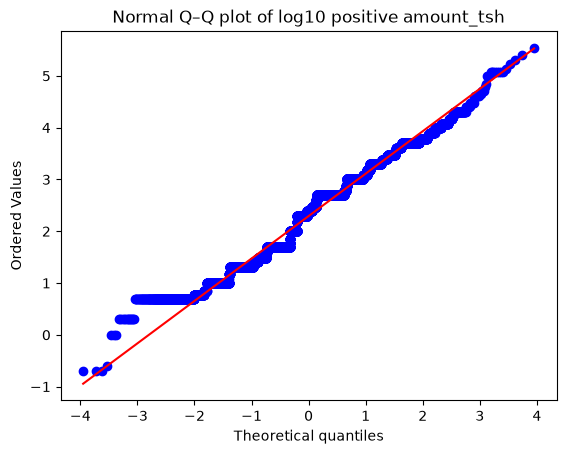

In [19]:
from scipy import stats
import matplotlib.pyplot as plt

stats.probplot(
    log_training_amounts,
    dist="norm",
    plot=plt
)

plt.title("Normal Q–Q plot of log10 positive amount_tsh")
plt.show()

In [20]:
training_amount_labels = (
    training_set_values[
        ["id", "amount_tsh"]
    ]
    .merge(
        training_set_labels,
        on="id",
        how="inner",
        validate="one_to_one"
    )
)

training_amount_labels.head()

,id,amount_tsh,status_group
0,69572,6000.0,functional
1,8776,0.0,functional
2,34310,25.0,functional
3,67743,0.0,non functional
4,19728,0.0,functional


In [21]:
def summarise_amounts_by_label(
    data: pd.DataFrame,
    *,
    amount_column: str = "amount_tsh",
    label_column: str = "status_group"
) -> pd.DataFrame:

    grouped = data.groupby(label_column)[amount_column]

    summary = grouped.agg(
        observations="size",
        missing=lambda values: values.isna().sum(),
        zero_count=lambda values: values.eq(0).sum(),
        positive_count=lambda values: values.gt(0).sum(),
        mean="mean",
        median="median",
        standard_deviation="std",
        minimum="min",
        percentile_75=lambda values: values.quantile(0.75),
        percentile_90=lambda values: values.quantile(0.90),
        percentile_95=lambda values: values.quantile(0.95),
        percentile_99=lambda values: values.quantile(0.99),
        maximum="max"
    )

    summary["zero_percentage"] = (
        summary["zero_count"]
        / summary["observations"]
        * 100
    )

    summary["positive_percentage"] = (
        summary["positive_count"]
        / summary["observations"]
        * 100
    )

    return summary[[
        "observations",
        "missing",
        "zero_count",
        "zero_percentage",
        "positive_count",
        "positive_percentage",
        "mean",
        "median",
        "standard_deviation",
        "minimum",
        "percentile_75",
        "percentile_90",
        "percentile_95",
        "percentile_99",
        "maximum"
    ]]

In [22]:
amount_by_status = summarise_amounts_by_label(
    training_amount_labels
)

amount_by_status.style.format({
    "observations": "{:,.0f}",
    "missing": "{:,.0f}",
    "zero_count": "{:,.0f}",
    "zero_percentage": "{:.2f}%",
    "positive_count": "{:,.0f}",
    "positive_percentage": "{:.2f}%",
    "mean": "{:,.2f}",
    "median": "{:,.2f}",
    "standard_deviation": "{:,.2f}",
    "minimum": "{:,.0f}",
    "percentile_75": "{:,.0f}",
    "percentile_90": "{:,.0f}",
    "percentile_95": "{:,.0f}",
    "percentile_99": "{:,.0f}",
    "maximum": "{:,.0f}"
})

,observations,missing,zero_count,zero_percentage,positive_count,positive_percentage,mean,median,standard_deviation,minimum,percentile_75,percentile_90,percentile_95,percentile_99,maximum
status_group,,,,,,,,,,,,,,,
functional,"32,259",0,"19,706",61.09%,"12,553",38.91%,461.80,0.00,"3,889.74",0,50,"1,000","2,000","6,000","350,000"
functional needs repair,"4,317",0,"3,048",70.60%,"1,269",29.40%,267.07,0.00,"1,925.03",0,50,500,"1,000","5,000","100,000"
non functional,"22,824",0,"18,885",82.74%,"3,939",17.26%,123.48,0.00,"1,110.12",0,0,70,500,"2,500","117,000"


In [23]:
training_amount_labels["has_recorded_amount"] = (
    training_amount_labels["amount_tsh"] > 0
)

amount_presence_by_status = pd.crosstab(
    training_amount_labels["status_group"],
    training_amount_labels["has_recorded_amount"],
    normalize="index"
).rename(columns={
    False: "Zero amount",
    True: "Positive amount"
}) * 100

amount_presence_by_status

has_recorded_amount,Zero amount,Positive amount
status_group,,
functional,61.086828,38.913172
functional needs repair,70.604587,29.395413
non functional,82.741851,17.258149


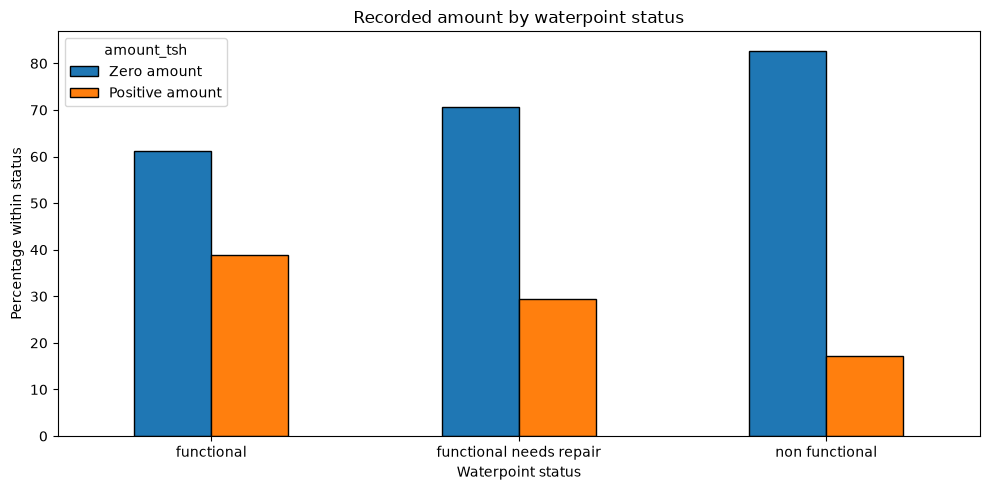

In [24]:
amount_presence_by_status.plot(
    kind="bar",
    figsize=(10, 5),
    edgecolor="black"
)

plt.xlabel("Waterpoint status")
plt.ylabel("Percentage within status")
plt.title("Recorded amount by waterpoint status")
plt.xticks(rotation=0)
plt.legend(title="amount_tsh")
plt.tight_layout()
plt.show()

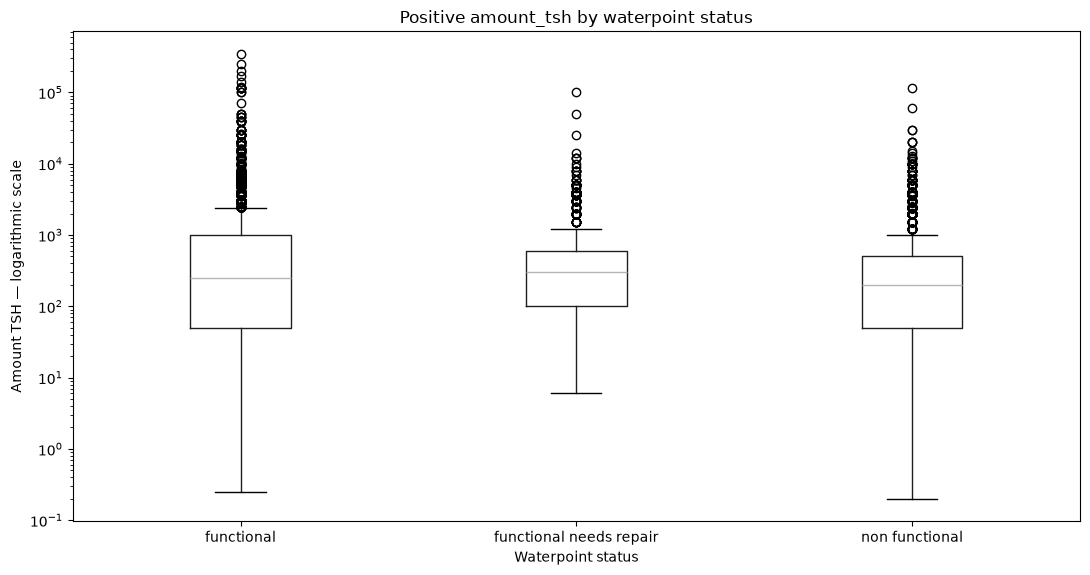

In [25]:
status_order = [
    "functional",
    "functional needs repair",
    "non functional",
]

positive_amount_labels = training_amount_labels.loc[
    training_amount_labels["amount_tsh"] > 0
].copy()

positive_amount_labels["status_group"] = pd.Categorical(
    positive_amount_labels["status_group"],
    categories=status_order,
    ordered=True
)

positive_amount_labels = positive_amount_labels.sort_values(
    "status_group"
)

positive_amount_labels.boxplot(
    column="amount_tsh",
    by="status_group",
    grid=False,
    figsize=(11, 6)
)

plt.yscale("log")
plt.xlabel("Waterpoint status")
plt.ylabel("Amount TSH — logarithmic scale")
plt.title("Positive amount_tsh by waterpoint status")
plt.suptitle("")
plt.tight_layout()
plt.show()

In [26]:
amount_bins = [
    -0.01,
    0,
    50,
    100,
    250,
    500,
    1000,
    5000,
    10000,
    float("inf")
]

amount_labels = [
    "Zero",
    "1–50",
    "51–100",
    "101–250",
    "251–500",
    "501–1,000",
    "1,001–5,000",
    "5,001–10,000",
    "Over 10,000"
]

training_amount_labels["amount_band"] = pd.cut(
    training_amount_labels["amount_tsh"],
    bins=amount_bins,
    labels=amount_labels
)

status_by_amount_band = pd.crosstab(
    training_amount_labels["amount_band"],
    training_amount_labels["status_group"],
    normalize="index"
) * 100

status_by_amount_band

status_group,functional,functional needs repair,non functional
amount_band,,,
Zero,47.325824,7.320061,45.354115
1–50,71.151515,3.878788,24.969697
51–100,67.523364,7.359813,25.116822
101–250,60.684705,15.129763,24.185533
251–500,70.829997,8.860422,20.309581
"501–1,000",70.233352,9.732499,20.034149
"1,001–5,000",75.436508,6.150794,18.412698
"5,001–10,000",80.344828,3.793103,15.862069
"Over 10,000",87.777778,3.888889,8.333333


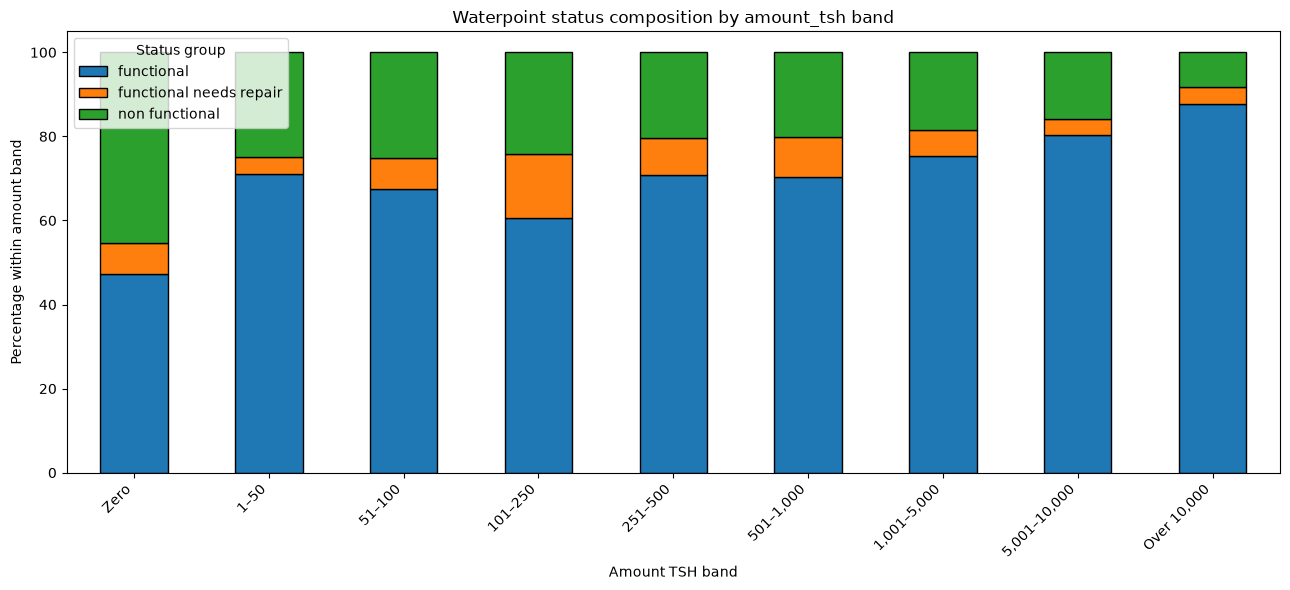

In [27]:
status_by_amount_band.plot(
    kind="bar",
    stacked=True,
    figsize=(13, 6),
    edgecolor="black"
)

plt.xlabel("Amount TSH band")
plt.ylabel("Percentage within amount band")
plt.title("Waterpoint status composition by amount_tsh band")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Status group")
plt.tight_layout()
plt.show()

In [28]:
status_by_amount_presence = pd.crosstab(
    training_amount_labels["has_recorded_amount"],
    training_amount_labels["status_group"],
    normalize="index"
).mul(100).rename(index={
    False: "Zero amount",
    True: "Positive amount"
})

status_by_amount_presence

status_group,functional,functional needs repair,non functional
has_recorded_amount,,,
Zero amount,47.325824,7.320061,45.354115
Positive amount,70.677327,7.144868,22.177805


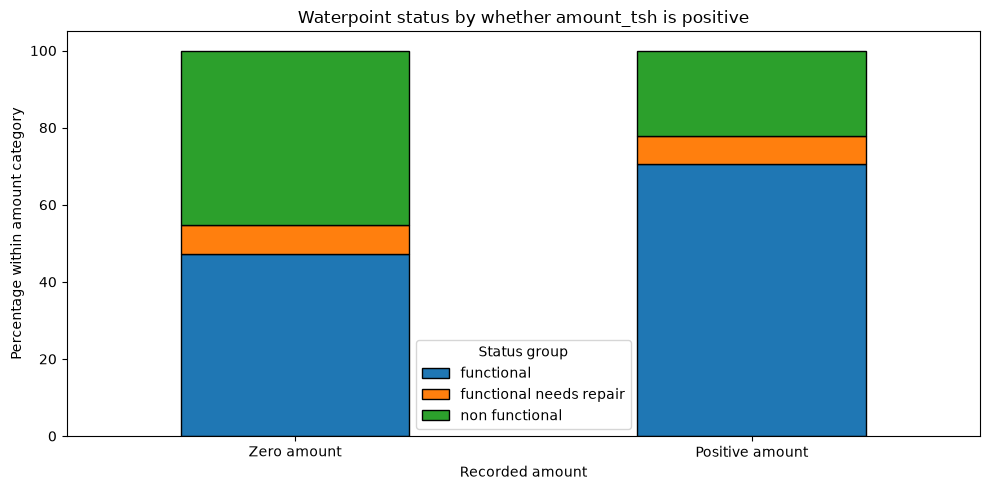

In [29]:
status_by_amount_presence.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 5),
    edgecolor="black"
)

plt.xlabel("Recorded amount")
plt.ylabel("Percentage within amount category")
plt.title("Waterpoint status by whether amount_tsh is positive")
plt.xticks(rotation=0)
plt.legend(title="Status group")
plt.tight_layout()
plt.show()

In [30]:
amount_band_counts = pd.crosstab(
    training_amount_labels["amount_band"],
    training_amount_labels["status_group"]
)

amount_band_percentages = pd.crosstab(
    training_amount_labels["amount_band"],
    training_amount_labels["status_group"],
    normalize="index"
).mul(100)

amount_band_percentages.insert(
    0,
    "observations",
    amount_band_counts.sum(axis=1)
)

amount_band_summary = pd.concat(
    {
        "Count": amount_band_counts,
        "Percentage": amount_band_percentages
    },
    axis=1
)

amount_band_summary

Count                                          Percentage  \
status_group functional functional needs repair non functional observations   
amount_band                                                                   
Zero              19706                    3048          18885        41639   
1–50               4696                     256           1648         6600   
51–100              578                      63            215          856   
101–250            1099                     274            438         1811   
251–500            2654                     332            761         3747   
501–1,000          1234                     171            352         1757   
1,001–5,000        1901                     155            464         2520   
5,001–10,000        233                      11             46          290   
Over 10,000         158                       7             15          180   

                                                                
status_group functional functional needs repair non functional  
amount_band                                                     
Zero          47.325824                7.320061      45.354115  
1–50          71.151515                3.878788      24.969697  
51–100        67.523364                7.359813      25.116822  
101–250       60.684705               15.129763      24.185533  
251–500       70.829997                8.860422      20.309581  
501–1,000     70.233352                9.732499      20.034149  
1,001–5,000   75.436508                6.150794      18.412698  
5,001–10,000  80.344828                3.793103      15.862069  
Over 10,000   87.777778                3.888889       8.333333

## Conclusions
amount_tsh contains a large concentration of zero values and an extremely long upper tail. Among positive observations, the highest 1% account for much of the extreme skewness and kurtosis, although the remaining values are still substantially right-skewed and heavy-tailed.

Most points track the red line of the Q-Q plot reasonably well, especially through the centre. That means log10(amount_tsh) is much closer to a normal distribution than amount_tsh itself.

Positive amount_tsh is approximately log-normal in its broad shape, but strongly heaped at repeated round monetary values and imperfect in the tails.

For modelling, a log transformation is therefore quite defensible:

    training_set_values["amount_tsh_log"] = np.log1p(
        training_set_values["amount_tsh"]
    )

log1p also handles zeroes, though I would retain a separate zero/positive indicator:

    training_set_values["amount_tsh_is_positive"] = (
        training_set_values["amount_tsh"] > 0
    )
## Relationship to the target

A positive `amount_tsh` is strongly associated with better waterpoint
status. Among observations with an amount of zero, 47.3% are functional
and 45.4% are non-functional. Among observations with a positive amount,
70.7% are functional and 22.2% are non-functional.

Higher positive amounts are also broadly associated with an increasing
functional share, particularly above approximately 500–1,000 TSh.
However, this relationship is not strictly monotonic across the lower
amount bands, and the highest bands contain fewer observations.

This is an association rather than evidence that charging or receiving
more money causes a waterpoint to function. `amount_tsh` may also proxy
for payment policy, management quality, population served, location or
whether a functioning waterpoint is capable of collecting payments.

For modelling, retain two derived signals:

- whether `amount_tsh` is positive;
- `log1p(amount_tsh)`, to preserve magnitude while compressing its
  extreme right tail.

The feature should later be considered alongside `payment`,
`payment_type`, region and other potentially related variables.
# Later Investigation
My LLM had some thoughts on this, including that some data points might be the aggregation of several nearby smaller datapoints, which themselves then get recorded as zero. 

I wonder if I could take this data, plus coordinate data, to generate a heatmap. Does the data give a way to differentiate 'aggregator' entries from non-aggregators? Is that even what's happening?

Revisit amount_tsh later during the deep relationship-to-target pass, particularly against:

* status_group
* payment
* payment_type
* region
* basin
